# BP 3.4 2025-2026 Opdracht 5:  Bejo 2026

### Projectinformatie
**Opleiding:** Toegepaste Wiskunde & Data Science  
**Vak:** Beroepsproject 3.4  
**Begeleider:** R. Nolet  
**Datum:** ?  

| Teamleden                  | Studentnummer |
|----------------------|---------------|
| Murielle Tichelaar    | 500926485     |
| Nalini Bisessar       | 500874334     |
| Lushan Strack         | 500934278     |
| Dinand Voogt          | 500934202     |


## Doel
Het doel van deze opdracht is om:



**Input:**  
- Trainingsdataset `data_train.csv` met klantkenmerken (belminuten, SMS-frequentie, gebruikspatronen)  
- Targetvariabele: `Churn` (blijft/vertrekt)




## Fase 1 - Business understanding
Het bedrijf BeJo meet de zaadkwaliteit van de zaden. Met behulp van Machine Vision is het gelukt om door het bladoppervlak een goede kwaliteitsvoorspelling te doen. Maar willen ze kijken of dit beter kan doormiddel van Deep learning. 

### Klasse
- Abnormaal: **0**
- Normaal: **1**

De klasse zijn verdeeld in 2 catogorieen. De afbeeldingen in de map abnormaal kennen we de waarde 0 toe en de afbeeldingen in de map Normaal krijgen de waarde 1. Als positieve klasse beschouwen we dat alle zaadjes gezond zijn. Dus in de negatieve klasse, hebben we het over dat alle zaadjes ongezond zijn. 

### Nulmodellen
Voor elk nulmodel wordt de precision, recall, F1-score en accurancy berekend. 

Alle zaden zijn gezond: **1**
- Accurancy: **86,2%**
- Precision: **86,2%**
- Recall: **100%**
- F1-score: **92,6%**


Alle zaden zijn ongezond: **0**
- Accurancy: **13,8%**
- Precision: **0,0%**
- Recall: **0,0%**
- F1-score: **0,0%**

Voor ieder zaadje is de kans dat het gezond is 85,8% 
- Accurancy: ** ?%**
- Precision: ** ?%**
- Recall: ** ?%**
- F1-score: ** ?%**

### Fracties gezonde zaadjes 
Elk zaadje wordt in zijn individu getest op de kwaliteit. 

Manieren voor bepalen van gezonde zaadjes 
- Aantal gezonde zaden gedeeld door het totaal aantal zaden. 
- Elke afbeelding wijst een kans toe. Over deze kansen kan het gemiddelde genomen worden.

Bepaal wat de voorspelde fractie gezonde zaden op de train data  is voor de nulmodellen 
- Alle zaden zijn gezond: **86,2%**
- Alle zaden zijn ongezond: **13,8%**
- Voor ieder zaadje is de kans dat het gezond is 85,8%: **?%**



## Fase 2 - Data Understanding

De dataset bestaat uit afbeeldingen van de plantjes. Van elke plant is een foto gemaakt van elke positie en gelabeld. Vervolgens moet er beoordeeld worden of het plantje een goed  of slecht resultaat oplevert. 


In [11]:
import os

###### Zet keras backend
os.environ["KERAS_BACKEND"] = "torch"

In [12]:
base_dir = r"C:\Users\murie\Desktop\opracht 5\BP-3.4\scripts\opdracht 5"

(1, 150, 150, 3)


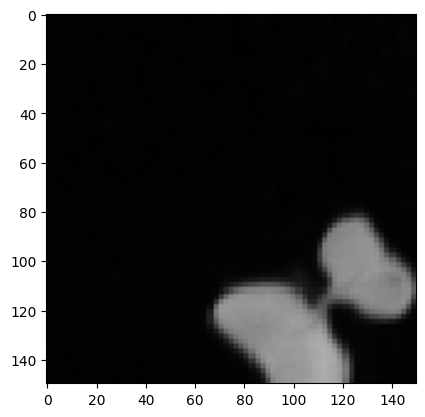

In [13]:
img_path = r'C:\Users\murie\Desktop\opracht 5\BP-3.4\scripts\opdracht 5\test\abnormal\0_H13_abnormal.png'

from keras.preprocessing import image
import keras.utils as image
import numpy as np
img = image.load_img(img_path, target_size=(150, 150))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.

print(img_tensor.shape)

#Afbeelding zelf
import matplotlib.pyplot as plt
plt.imshow(img_tensor[0])
plt.show()

In [21]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    base_dir + r"\\train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(74, 74),
    batch_size=32
)

val_dataset = image_dataset_from_directory(
    base_dir + r"\\train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(74, 74),
    batch_size=32
)

test_dataset = image_dataset_from_directory(
    base_dir + "\\test",
    image_size=(74, 74),
    batch_size=32
)

print(train_dataset.class_names)

Found 11758 files belonging to 2 classes.
Using 9407 files for training.
Found 11758 files belonging to 2 classes.
Using 2351 files for validation.
Found 2940 files belonging to 2 classes.
['abnormal', 'normal']


In [ ]:
type(train_dataset)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [22]:
for data_batch, labels_batch in train_dataset:
     print("data batch shape:", data_batch.shape)
     print("labels batch shape:", labels_batch.shape)
     break

data batch shape: (32, 74, 74, 3)
labels batch shape: (32,)


In [23]:
###### Code-III.5 ######
from tensorflow import keras 
from tensorflow.keras import layers

inputs = keras.Input(shape=(74, 74, 3)) # model rekent op afbeeldingen van 74 x 74 pixels in 3 (kleur)lagen                  
x = layers.Rescaling(1./255)(inputs)   # herschaal de pixelwaarden naar waarde tussen 0 en 1                             
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x) 
outputs = layers.Dense(1, activation="sigmoid")(x)
model_start = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model_start.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 74, 74, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 74, 74, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 72, 72, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,183,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,203,265 (4.59 MB)

 Trainable params: 1,203,265 (4.59 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
###### Code-III.6 ######
model_start.compile(loss="binary_crossentropy", # binaire classificatie
              optimizer="rmsprop",              # optimalisatiealgoritme tijdens trainen
              metrics=["precision"])             # metric om bij te houden tijdens trainen

# definieer callbacks - zoek zelf eens wat hier nog meer kan! Handig voor je eindopdracht?
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,  # Na iedere epoch wordt naar waarde in 'monitor' gekeken: 
        monitor="val_precision",   # als precision hoog is: bewaar dit model.
        mode="max")
]

In [31]:
history = model_start.fit(
    train_dataset,
    epochs=12,
    validation_data=val_dataset,
    callbacks=callbacks)

Epoch 1/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 69s 235ms/step - loss: 0.1697 - precision: 0.9555 - val_loss: 0.1795 - val_precision: 0.9513
Epoch 2/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 67s 228ms/step - loss: 0.1642 - precision: 0.9562 - val_loss: 0.1843 - val_precision: 0.9549
Epoch 3/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 68s 232ms/step - loss: 0.1593 - precision: 0.9570 - val_loss: 0.1760 - val_precision: 0.9495
Epoch 4/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 72s 246ms/step - loss: 0.1551 - precision: 0.9580 - val_loss: 0.1792 - val_precision: 0.9503
Epoch 5/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 71s 242ms/step - loss: 0.1498 - precision: 0.9594 - val_loss: 0.1847 - val_precision: 0.9556
Epoch 6/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 74s 252ms/step - loss: 0.1434 - precision: 0.9615 - val_loss: 0.1849 - val_precision: 0.9521
Epoch 7/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 77s 263ms/step - loss: 0.1379 - precision: 0.9618 - val_loss: 0.1963 - val_precision: 0.9588
Epoch 8/12
294/294 ━━━━━━━━━━━━━━━━━━━━ 75s 256ms/step - loss: 0.1294

294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - loss: 0.1007 - precision: 0.9710
Test precision: 0.9709951281547546


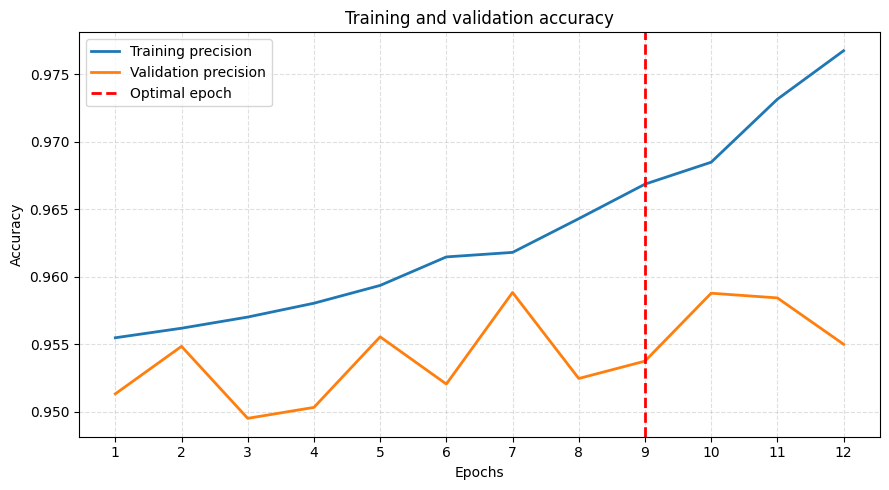

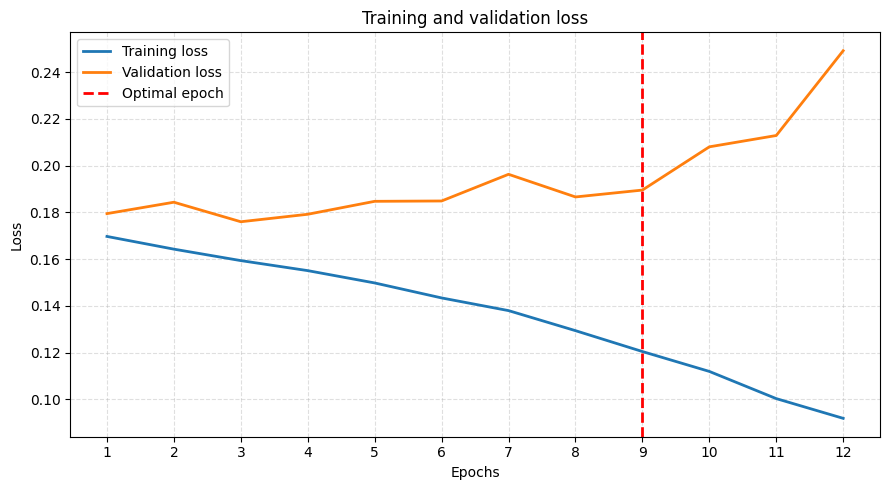

In [39]:
test_loss, test_precision = model_start.evaluate(train_dataset)
print("Test precision:", test_precision)   

precision = history.history['precision']
val_precision = history.history['val_precision']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(precision) + 1)

plt.figure(figsize=(9,5))
plt.plot(epochs, precision, linewidth=2, label="Training precision")
plt.plot(epochs, val_precision, linewidth=2, label="Validation precision")
plt.axvline(x=9, color='red', linestyle='--',linewidth=2, label='Optimal epoch')
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
plt.plot(epochs, loss, linewidth=2, label="Training loss")
plt.plot(epochs, val_loss, linewidth=2, label="Validation loss")
plt.axvline(x=9, color='red', linestyle='--',linewidth=2, label='Optimal epoch')
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()